### **Análise Exploratória:**

In [4]:
# Configuração do Path e imports básicos
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import seaborn as sns
import sys

# Configurar path para importar módulos da pasta src
sys.path.append('..')

In [5]:
# Geração dos dados sintéticos
np.random.seed(42)
n_customers = 10000

# 1. Gerar clientes
clientes = pd.DataFrame({
    'id_cliente': range(1, n_customers + 1),
    'idade': np.random.normal(35, 12, n_customers).astype(int),
    'genero': np.random.choice(['M', 'F'], n_customers),
    'cidade': np.random.choice(['SP', 'RJ', 'BH', 'BSB', 'POA'], n_customers, 
                               p=[0.4, 0.3, 0.1, 0.1, 0.1]),
    'data_cadastro': pd.date_range(start='2020-01-01', end='2024-01-01', periods=n_customers),
    'canal_aquisicao': np.random.choice(['Google', 'Facebook', 'Indicação', 'Orgânico'], 
                                        n_customers, p=[0.3, 0.2, 0.2, 0.3]),
})

# 2. Gerar transações com padrões realistas
transacoes = []
churn_logic = []

for idx, row in clientes.iterrows():
    id_cliente = row['id_cliente']
    idade = row['idade']
    cidade = row['cidade']
    canal = row['canal_aquisicao']
    data_cadastro = row['data_cadastro']
    
    # Número de compras baseado em características
    n_compras_base = 5
    
    if idade < 25:
        n_compras_base += 3
    elif idade > 50:
        n_compras_base -= 2
    
    if canal == 'Indicação':
        n_compras_base += 2
    elif canal == 'Google':
        n_compras_base += 1
    
    if cidade == 'SP':
        n_compras_base += 2
    elif cidade == 'RJ':
        n_compras_base += 1
    
    n_compras = max(1, int(np.random.poisson(n_compras_base)))
    
    # Gerar compras
    for _ in range(n_compras):
        dias_apos_cadastro = np.random.exponential(90)
        data_compra = data_cadastro + timedelta(days=int(dias_apos_cadastro))
        
        valor_base = 150
        if idade > 40:
            valor_base += 50
        if canal == 'Indicação':
            valor_base += 30
        
        valor = np.random.gamma(2, valor_base/2)
        
        transacoes.append({
            'id_cliente': id_cliente,
            'data_compra': data_compra,
            'valor': round(valor, 2),
            'categoria': np.random.choice(['Eletrônicos', 'Moda', 'Casa', 'Esportes', 'Beleza'],
                                         p=[0.2, 0.3, 0.2, 0.15, 0.15]),
            'metodo_pagamento': np.random.choice(['Cartão', 'Boleto', 'Pix'], 
                                                p=[0.6, 0.2, 0.2])
        })
    
    # Calcular probabilidade de churn 
    prob_churn = 0.3
    
    if n_compras < 3:
        prob_churn += 0.3
    elif n_compras > 8:
        prob_churn -= 0.2
    
    if canal == 'Facebook':
        prob_churn += 0.1
    elif canal == 'Indicação':
        prob_churn -= 0.15
    
    if cidade == 'BSB':
        prob_churn += 0.1
    elif cidade == 'SP':
        prob_churn -= 0.1
    
    if idade < 25:
        prob_churn -= 0.05
    elif idade > 60:
        prob_churn += 0.1
    
    prob_churn = np.clip(prob_churn, 0.05, 0.8)
    churn_logic.append(prob_churn)

# Adicionar churn
clientes['churn'] = [np.random.binomial(1, p) for p in churn_logic]
clientes = clientes.drop('data_cadastro', axis=1)  # remove coluna antiga

# Criar DataFrame de transações
transacoes = pd.DataFrame(transacoes)

# Salvar
clientes.to_csv('../data/raw/clientes.csv', index=False)
transacoes.to_csv('../data/raw/transacoes.csv', index=False)

print(f"Dados gerados com sucesso!")
print(f"Clientes: {len(clientes)}")
print(f"Transações: {len(transacoes)}")
print(f"Taxa de churn: {clientes['churn'].mean()*100:.2f}%")

Dados gerados com sucesso!
Clientes: 10000
Transações: 72294
Taxa de churn: 22.26%


In [6]:
# Carregar dados
try:
    # Tenta importar com o nome correto doarquivo
    from src.data_processing import carregar_dados
    
    clientes, transacoes = carregar_dados()
    print("Dados carregados com sucesso via módulo!")
    
except ImportError:
    print("Módulo não encontrado. Carregando dados diretamente...")
    
    # Carregar diretamente os CSVs
    clientes = pd.read_csv('../data/raw/clientes.csv')
    transacoes = pd.read_csv('../data/raw/transacoes.csv')
    
    print("Dados carregados diretamente dos CSVs!")
    
except Exception as e:
    print(f"Erro inesperado: {e}")
    # Fallback para carregamento direto
    clientes = pd.read_csv('../data/raw/clientes.csv')
    transacoes = pd.read_csv('../data/raw/transacoes.csv')

# Verificar se carregou corretamente
print(f"\nResumo dos dados:")
print(f"Clientes: {clientes.shape}")
print(f"Transações: {transacoes.shape}")
print(f"\nPrimeiras linhas de clientes:")
print(clientes.head())

Módulo não encontrado. Carregando dados diretamente...
Dados carregados diretamente dos CSVs!

Resumo dos dados:
Clientes: (10000, 6)
Transações: (72294, 5)

Primeiras linhas de clientes:
   id_cliente  idade genero cidade canal_aquisicao  churn
0           1     40      F     RJ          Google      0
1           2     33      F     RJ          Google      0
2           3     42      M     SP       Indicação      0
3           4     53      M     BH        Orgânico      1
4           5     32      M     BH        Orgânico      1


In [7]:
# Análise Descritiva Básica

print("="*50)
print("ANÁLISE DESCRITIVA DOS DADOS")
print("="*50)

# Estatísticas descritivas
print("\nEstatísticas das variáveis numéricas - Clientes:")
print(clientes.describe())

print("\nEstatísticas das variáveis categóricas - Clientes:")
print(clientes.describe(include=['object']))

print("\nEstatísticas das transações:")
print(transacoes.describe())

# Valores ausentes
print("\nValores ausentes - Clientes:")
print(clientes.isnull().sum())

print("\nValores ausentes - Transações:")
print(transacoes.isnull().sum())

# Taxa de churn geral
taxa_churn_geral = clientes['churn'].mean() * 100
print(f"\nTAXA DE CHURN GERAL: {taxa_churn_geral:.2f}%")

ANÁLISE DESCRITIVA DOS DADOS

Estatísticas das variáveis numéricas - Clientes:
        id_cliente         idade         churn
count  10000.00000  10000.000000  10000.000000
mean    5000.50000     34.478400      0.222600
std     2886.89568     12.038622      0.416013
min        1.00000    -12.000000      0.000000
25%     2500.75000     26.000000      0.000000
50%     5000.50000     34.000000      0.000000
75%     7500.25000     43.000000      0.000000
max    10000.00000     82.000000      1.000000

Estatísticas das variáveis categóricas - Clientes:
       genero cidade canal_aquisicao
count   10000  10000           10000
unique      2      5               4
top         F     SP          Google
freq     5082   3901            3055

Estatísticas das transações:
         id_cliente         valor
count  72294.000000  72294.000000
mean    5007.911486    170.237450
std     2889.744320    124.772043
min        1.000000      0.370000
25%     2499.000000     79.455000
50%     5004.000000    141.

### **Análise de Churn por Variáveis Categóricas:**

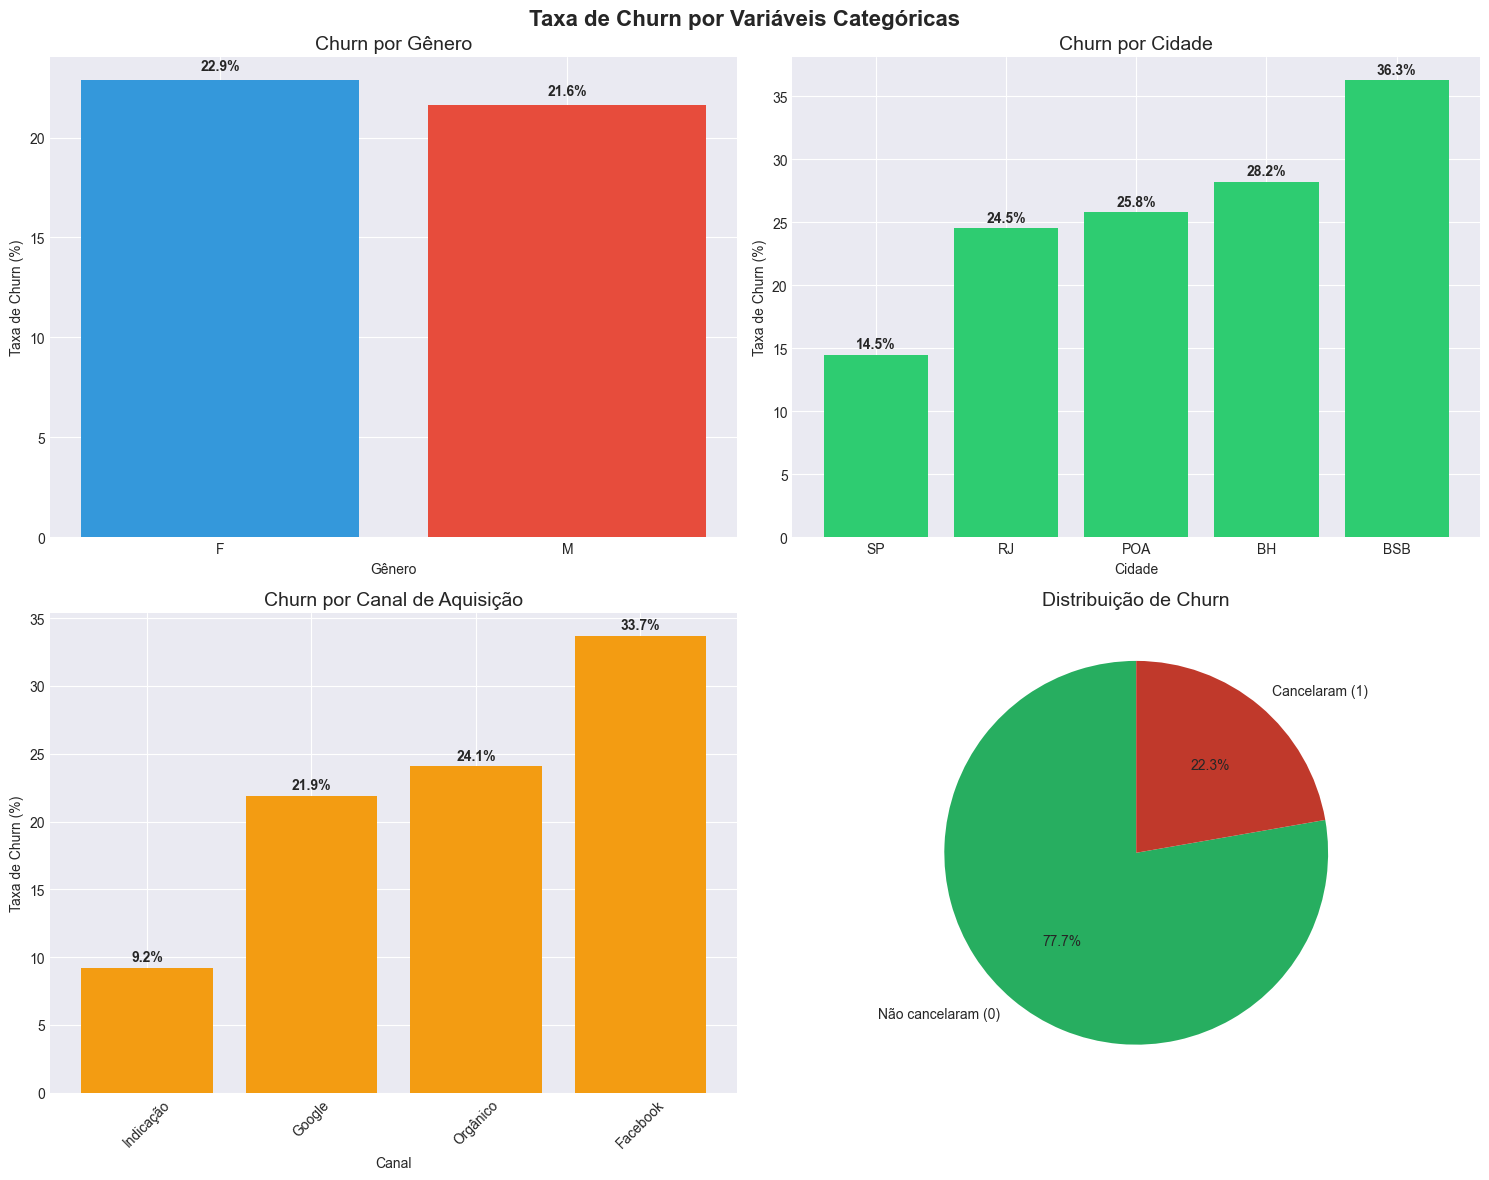

In [8]:
# Configurar estilo dos gráficos
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("viridis")

# Criar subplots
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('Taxa de Churn por Variáveis Categóricas', fontsize=16, fontweight='bold')

# 1. Churn x Gênero
churn_genero = clientes.groupby('genero')['churn'].mean() * 100
axes[0, 0].bar(churn_genero.index, churn_genero.values, color=['#3498db', '#e74c3c'])
axes[0, 0].set_title('Churn por Gênero', fontsize=14)
axes[0, 0].set_ylabel('Taxa de Churn (%)')
axes[0, 0].set_xlabel('Gênero')
for i, v in enumerate(churn_genero.values):
    axes[0, 0].text(i, v + 0.5, f'{v:.1f}%', ha='center', fontweight='bold')

# 2. Churn x Cidade
churn_cidade = clientes.groupby('cidade')['churn'].mean() * 100
churn_cidade = churn_cidade.sort_values()
axes[0, 1].bar(churn_cidade.index, churn_cidade.values, color='#2ecc71')
axes[0, 1].set_title('Churn por Cidade', fontsize=14)
axes[0, 1].set_ylabel('Taxa de Churn (%)')
axes[0, 1].set_xlabel('Cidade')
for i, v in enumerate(churn_cidade.values):
    axes[0, 1].text(i, v + 0.5, f'{v:.1f}%', ha='center', fontweight='bold')

# 3. Churn x Canal de Aquisição
churn_canal = clientes.groupby('canal_aquisicao')['churn'].mean() * 100
churn_canal = churn_canal.sort_values()
axes[1, 0].bar(churn_canal.index, churn_canal.values, color='#f39c12')
axes[1, 0].set_title('Churn por Canal de Aquisição', fontsize=14)
axes[1, 0].set_ylabel('Taxa de Churn (%)')
axes[1, 0].set_xlabel('Canal')
axes[1, 0].tick_params(axis='x', rotation=45)
for i, v in enumerate(churn_canal.values):
    axes[1, 0].text(i, v + 0.5, f'{v:.1f}%', ha='center', fontweight='bold')

# 4. Distribuição de Churn
churn_counts = clientes['churn'].value_counts()
labels = ['Não cancelaram (0)', 'Cancelaram (1)']
colors = ['#27ae60', '#c0392b']
axes[1, 1].pie(churn_counts.values, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90)
axes[1, 1].set_title('Distribuição de Churn', fontsize=14)

plt.tight_layout()
plt.savefig('../reports/figures/churn_categorico.png', dpi=300, bbox_inches='tight')
plt.show()

C:\Users\Dell Vostro\AppData\Local\Temp\ipykernel_10932\1889772354.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=clientes, x='churn', y='idade', ax=axes[1], palette=['#27ae60', '#c0392b'])
C:\Users\Dell Vostro\AppData\Local\Temp\ipykernel_10932\1889772354.py:24: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  churn_faixa = clientes.groupby('faixa_etaria')['churn'].mean() * 100


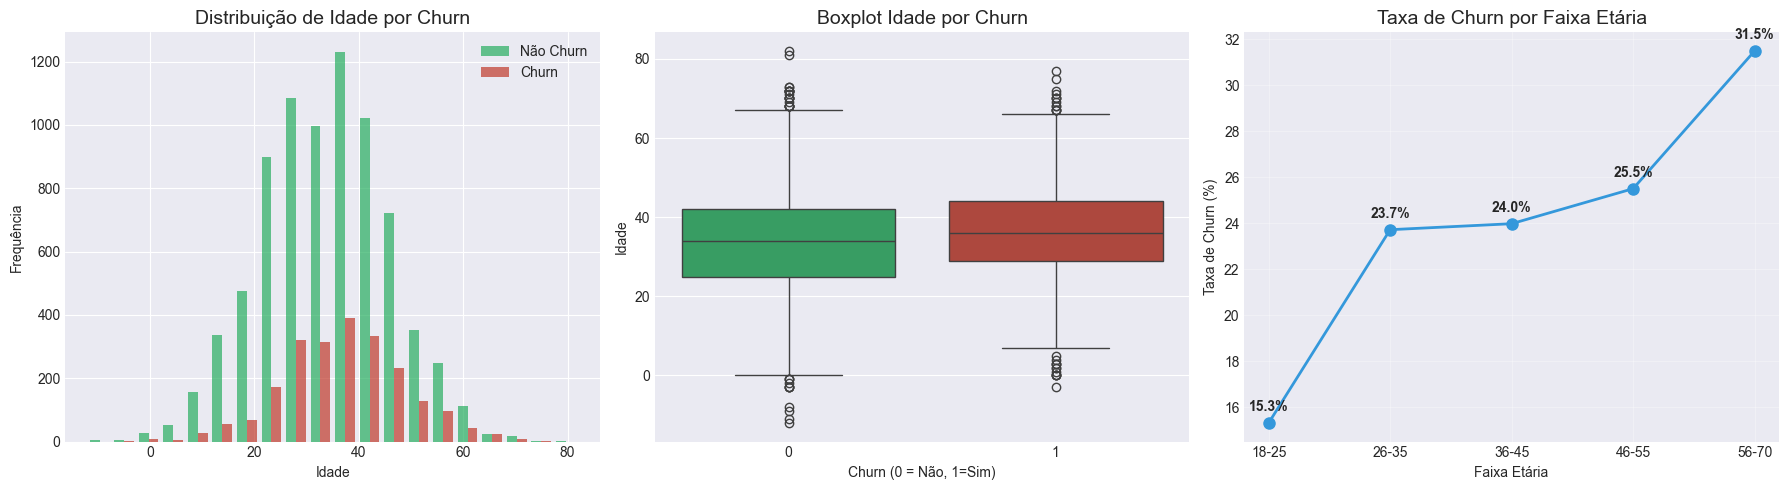

In [9]:
# Relação entre Idade e Churn

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Distribuição de idade por churn
axes[0].hist([clientes[clientes['churn']==0]['idade'], 
              clientes[clientes['churn']==1]['idade']], 
             label=['Não Churn', 'Churn'], 
             bins=20, alpha=0.7, color=['#27ae60', '#c0392b'])
axes[0].set_title('Distribuição de Idade por Churn', fontsize=14)
axes[0].set_xlabel('Idade')
axes[0].set_ylabel('Frequência')
axes[0].legend()

# 2. Boxplot idade por churn
sns.boxplot(data=clientes, x='churn', y='idade', ax=axes[1], palette=['#27ae60', '#c0392b'])
axes[1].set_title('Boxplot Idade por Churn', fontsize=14)
axes[1].set_xlabel('Churn (0 = Não, 1=Sim)')
axes[1].set_ylabel('Idade')

# 3. Taxa de churn por faixa etária
clientes['faixa_etaria'] = pd.cut(clientes['idade'], bins=[18, 25, 35, 45, 55, 70],
                                 labels=['18-25', '26-35', '36-45', '46-55', '56-70'])
churn_faixa = clientes.groupby('faixa_etaria')['churn'].mean() * 100
axes[2].plot(churn_faixa.index.astype(str), churn_faixa.values, marker='o', linewidth=2,
            markersize=8, color='#3498db')
axes[2].set_title('Taxa de Churn por Faixa Etária', fontsize=14)
axes[2].set_xlabel('Faixa Etária')
axes[2].set_ylabel('Taxa de Churn (%)')
axes[2].grid(True, alpha=0.3)
for i, v in enumerate(churn_faixa.values):
    axes[2].text(i, v + 0.5, f'{v:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('../reports/figures/churn_idade.png', dpi=300, bbox_inches='tight')
plt.show()

### **Análise de Comportamento de Compra:**

Estatísticas de compras por cliente:
        valor_total  ticket_medio   qtd_compras
count  10000.000000  10000.000000  10000.000000
mean    1230.714620    171.815191      7.229400
std      653.176052     60.080496      3.225867
min       26.840000     23.490000      1.000000
25%      759.165000    131.907500      5.000000
50%     1138.845000    163.655000      7.000000
75%     1603.535000    202.662500      9.000000
max     5768.450000    840.460000     23.000000


C:\Users\Dell Vostro\AppData\Local\Temp\ipykernel_10932\1080430286.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=clientes_completo, x='churn', y='valor_total', ax=axes[0, 0], palette=['#27ae60', '#c0392b'])
C:\Users\Dell Vostro\AppData\Local\Temp\ipykernel_10932\1080430286.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=clientes_completo, x='churn', y='qtd_compras', ax=axes[0, 1], palette=['#27ae60', '#c0392b'])
C:\Users\Dell Vostro\AppData\Local\Temp\ipykernel_10932\1080430286.py:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  s

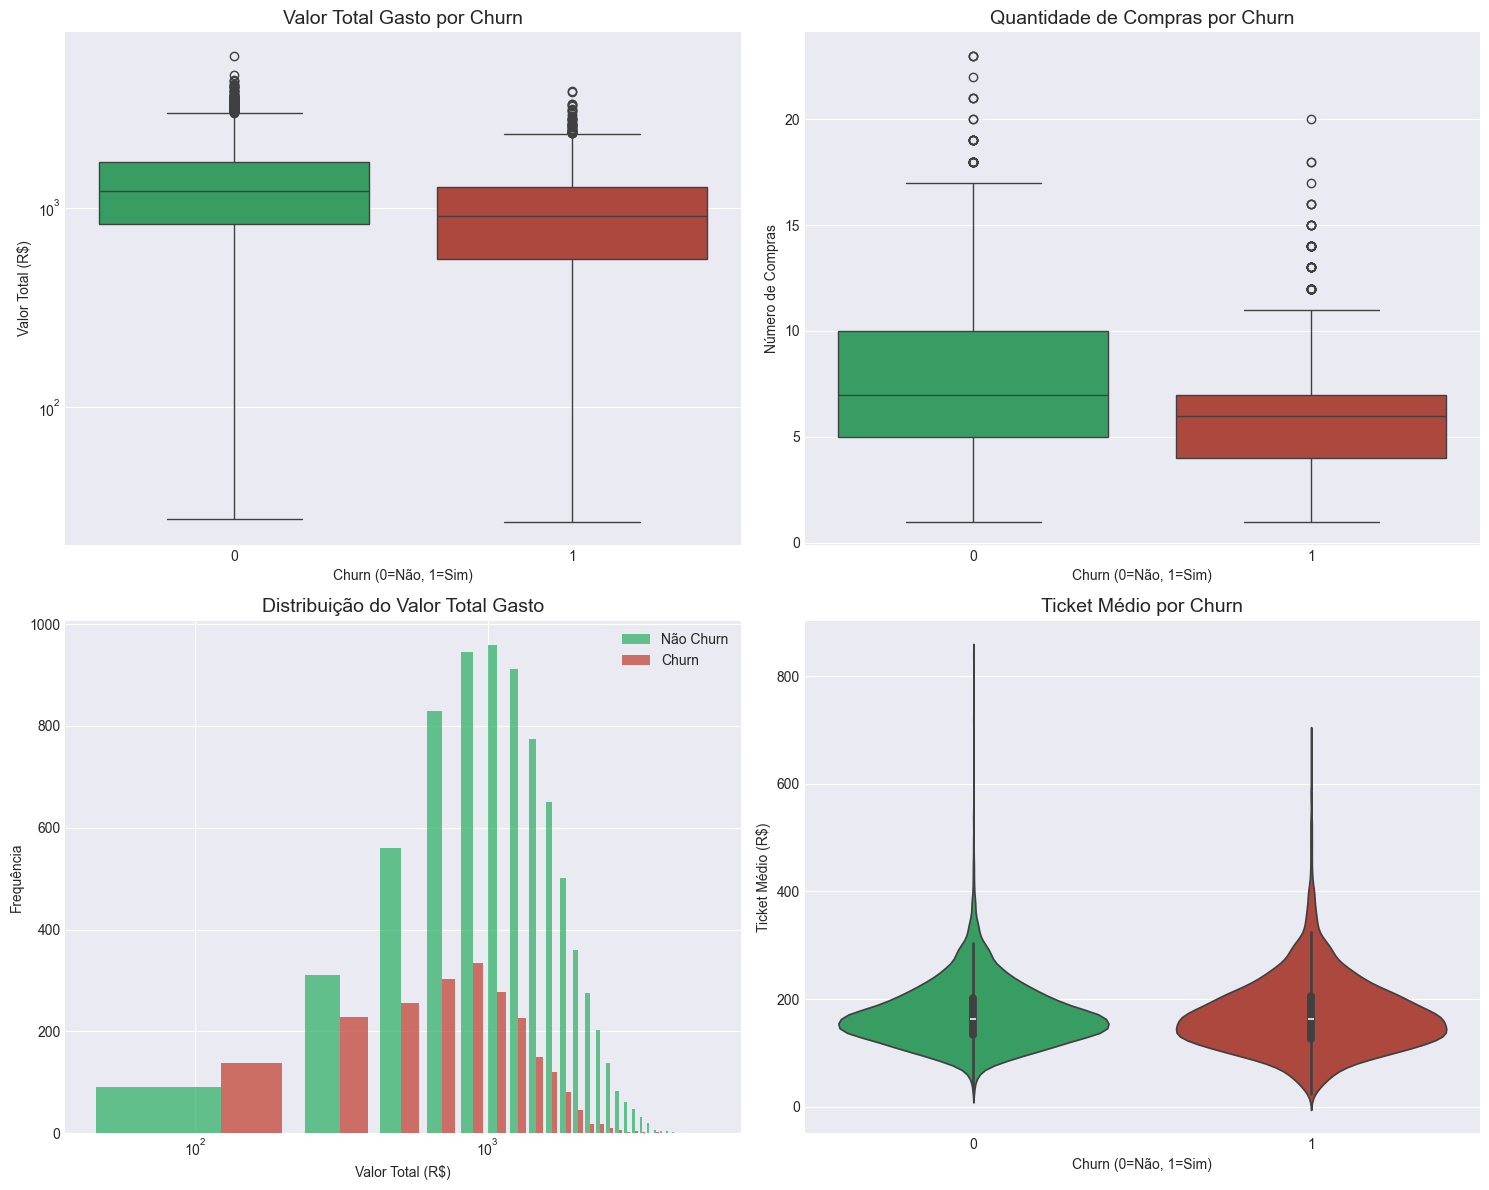

In [10]:
# Métricas de compra por cliente
# Agrupar transações por clientes
compras_cliente = transacoes.groupby('id_cliente').agg({
    'valor': ['sum', 'mean', 'count'],
    'data_compra': ['min', 'max']
}).round(2)

# Renomear colunas
compras_cliente.columns = ['valor_total', 'ticket_medio', 'qtd_compras', 'primeira_compra',
                          'última_compra']
compras_cliente = compras_cliente.reset_index()

# Fazer merge com dados dos clientes
clientes_completo = clientes.merge(compras_cliente, on='id_cliente', how='left')

# Preencher valores para clientes sem compras
clientes_completo['qtd_compras'] = clientes_completo['qtd_compras'].fillna(0)
clientes_completo['valor_total'] = clientes_completo['valor_total'].fillna(0)
clientes_completo['ticket_medio'] = clientes_completo['ticket_medio'].fillna(0)

print("Estatísticas de compras por cliente:")
print(clientes_completo[['valor_total', 'ticket_medio', 'qtd_compras']].describe())

# Visualizações
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 1. Boxplot valor total por churn
sns.boxplot(data=clientes_completo, x='churn', y='valor_total', ax=axes[0, 0], palette=['#27ae60', '#c0392b'])
axes[0, 0].set_title('Valor Total Gasto por Churn', fontsize=14)
axes[0, 0].set_xlabel('Churn (0=Não, 1=Sim)')
axes[0, 0].set_ylabel('Valor Total (R$)')
axes[0, 0].set_yscale('log')  # escala log devido a outliers

# 2. Boxplot quantidade de compras por churn
sns.boxplot(data=clientes_completo, x='churn', y='qtd_compras', ax=axes[0, 1], palette=['#27ae60', '#c0392b'])
axes[0, 1].set_title('Quantidade de Compras por Churn', fontsize=14)
axes[0, 1].set_xlabel('Churn (0=Não, 1=Sim)')
axes[0, 1].set_ylabel('Número de Compras')

# 3. Distribuição do valor total (churn x não churn)
axes[1, 0].hist([clientes_completo[clientes_completo['churn']==0]['valor_total'],
                 clientes_completo[clientes_completo['churn']==1]['valor_total']],
                label=['Não Churn', 'Churn'], bins=30, alpha=0.7, color=['#27ae60', '#c0392b'])
axes[1, 0].set_title('Distribuição do Valor Total Gasto', fontsize=14)
axes[1, 0].set_xlabel('Valor Total (R$)')
axes[1, 0].set_ylabel('Frequência')
axes[1, 0].legend()
axes[1, 0].set_xscale('log')

# 4. Ticket médio por churn
sns.violinplot(data=clientes_completo, x='churn', y='ticket_medio', ax=axes[1, 1], palette=['#27ae60', '#c0392b'])
axes[1, 1].set_title('Ticket Médio por Churn', fontsize=14)
axes[1, 1].set_xlabel('Churn (0=Não, 1=Sim)')
axes[1, 1].set_ylabel('Ticket Médio (R$)')

plt.tight_layout()
plt.savefig('../reports/figures/churn_compras.png', dpi=300, bbox_inches='tight')
plt.show()

### **Análise Temporal:**

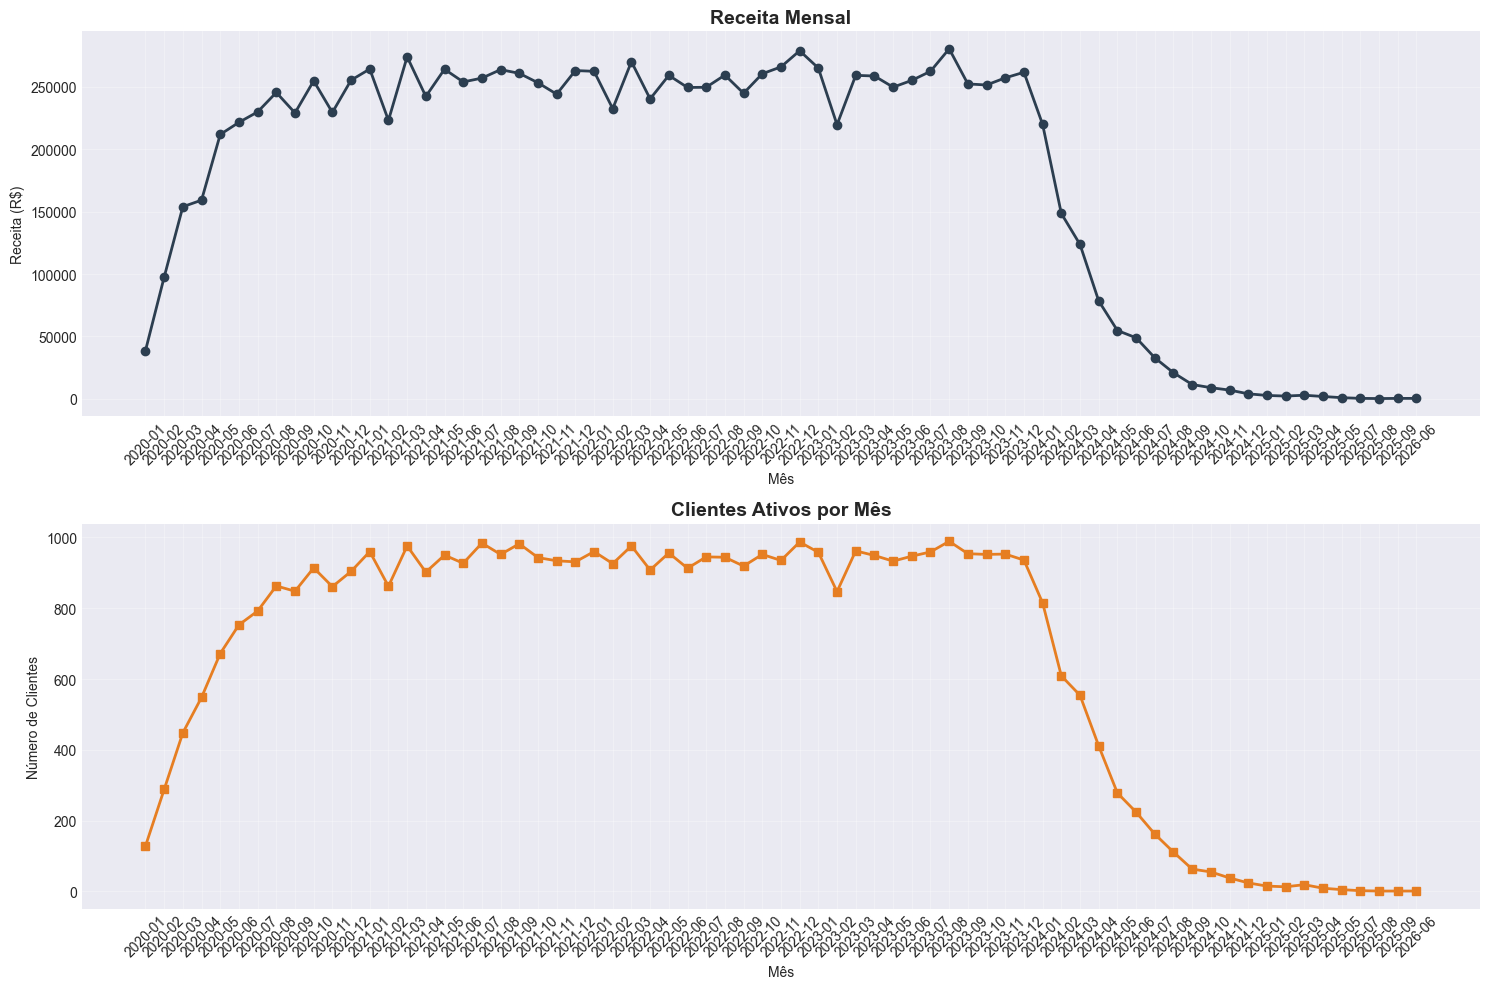

In [11]:
# Converter datas
transacoes['data_compra'] = pd.to_datetime(transacoes['data_compra'])
transacoes['mes_ano'] = transacoes['data_compra'].dt.to_period('M')

# Vendas ao longo do tempo
vendas_mensais = transacoes.groupby('mes_ano').agg({
    'valor': 'sum',
    'id_cliente': 'nunique'
}).reset_index()
vendas_mensais['mes_ano'] = vendas_mensais['mes_ano'].astype(str)

fig, axes = plt.subplots(2, 1, figsize=(15, 10))

# 1. Receita mensal
axes[0].plot(vendas_mensais['mes_ano'], vendas_mensais['valor'], marker='o', linewidth=2, color='#2c3e50')
axes[0].set_title('Receita Mensal', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Mês')
axes[0].set_ylabel('Receita (R$)')
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(True, alpha=0.3)

# 2. Clientes ativos por mês
axes[1].plot(vendas_mensais['mes_ano'], vendas_mensais['id_cliente'], marker='s', linewidth=2, color='#e67e22')
axes[1].set_title('Clientes Ativos por Mês', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Mês')
axes[1].set_ylabel('Número de Clientes')
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../reports/figures/analise_temporal.png', dpi=300, bbox_inches='tight')
plt.show()

### **Principais Insights:**

In [12]:
print("="*60)
print("PRINCIPAIS INSIGHTS DA ANÁLISE EXPLORATÓRIA")
print("="*60)

# Taxa de churn geral
print(f"\n1. TAXA DE CHURN GERAL: {taxa_churn_geral:.2f}%")
print(f"  - De cada 100 clientes, {taxa_churn_geral:.1f} cancelam")

# Melhor e pior canal
melhor_canal = churn_canal.idxmin()
pior_canal = churn_canal.idxmax()
print(f"\n2. CANAIS DE AQUISIÇÃO:")
print(f"   - Melhor canal (menor churn): {melhor_canal} ({churn_canal[melhor_canal]:.1f}%)")
print(f"   - Pior canal (maior churn): {pior_canal} ({churn_canal[pior_canal]:.1f}%)")

# Cidades
melhor_cidade = churn_cidade.idxmin()
pior_cidade = churn_cidade.idxmax()
print(f"\n3. CIDADES:")
print(f"   - Melhor cidade (menor churn): {melhor_cidade} ({churn_cidade[melhor_cidade]:.1f}%)")
print(f"   - Pior cidade (maior churn): {pior_cidade} ({churn_cidade[pior_cidade]:.1f}%)")

# Comportamento de compra
churn_medio_compras = clientes_completo.groupby('churn')['qtd_compras'].mean()
print(f"\n4. COMPORTAMENTO DE COMPRA:")
print(f"   - Clientes que não cancelaram: média de {churn_medio_compras[0]:.1f} compras")
print(f"   - Clientes que cancelaram: média de {churn_medio_compras[1]:.1f} compras")
print(f"   - Diferença: {churn_medio_compras[0] - churn_medio_compras[1]:.1f} compras a menos")

# Ticket médio
ticket_medio_churn = clientes_completo.groupby('churn')['ticket_medio'].mean()
print(f"\n5.  TICKET MÉDIO:")
print(f"   - Não churn: R$ {ticket_medio_churn[0]:.2f}")
print(f"   - Churn: R$ {ticket_medio_churn[1]:.2f}")

# Faixa etária de maior risco
faixa_risco = churn_faixa.idxmax()
print(f"\n6. FAIXA ETÁRIA:")
print(f"   - Maior risco de churn: {faixa_risco} ({churn_faixa[faixa_risco]:.1f}%)")

print("\n" + "="*60)
print("Análise exploratória concluída!")
print("="*60)

PRINCIPAIS INSIGHTS DA ANÁLISE EXPLORATÓRIA

1. TAXA DE CHURN GERAL: 22.26%
  - De cada 100 clientes, 22.3 cancelam

2. CANAIS DE AQUISIÇÃO:
   - Melhor canal (menor churn): Indicação (9.2%)
   - Pior canal (maior churn): Facebook (33.7%)

3. CIDADES:
   - Melhor cidade (menor churn): SP (14.5%)
   - Pior cidade (maior churn): BSB (36.3%)

4. COMPORTAMENTO DE COMPRA:
   - Clientes que não cancelaram: média de 7.7 compras
   - Clientes que cancelaram: média de 5.7 compras
   - Diferença: 2.0 compras a menos

5.  TICKET MÉDIO:
   - Não churn: R$ 172.02
   - Churn: R$ 171.09

6. FAIXA ETÁRIA:
   - Maior risco de churn: 56-70 (31.5%)

Análise exploratória concluída!
